In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
df = pd.read_excel('/Users/amirmojab/Desktop/ML Course/ml_samples.xlsx', sheet_name='salary')

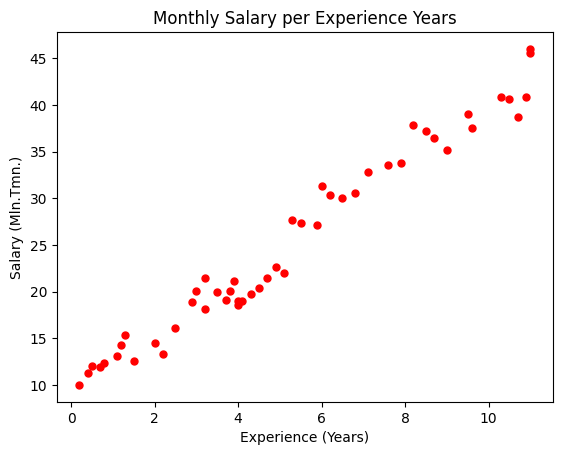

In [7]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'],
           y=df['salary_linear'],
           c='r', 
           s=25)

ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.show()

In [8]:
model_reg_lin = LinearRegression()

model_reg_lin.fit(
    X=df['experience_years'].to_numpy().reshape(-1, 1),
    y=df['salary_linear']
)

LinearRegression()

In [40]:
model_reg_lin.coef_, model_reg_lin.intercept_

(array([3.10655835]), 9.032109713058677)

In [41]:
# Let's do this on our own!
experience = df['experience_years'].to_numpy() - df['experience_years'].mean()
salary = df['salary_linear'].to_numpy() - df['salary_linear'].mean()

m = np.multiply(salary, experience).sum() / (experience ** 2).sum()
b = df['salary_linear'].mean() - m * df['experience_years'].mean()

m, b

(3.106558346852889, 9.032109713058684)

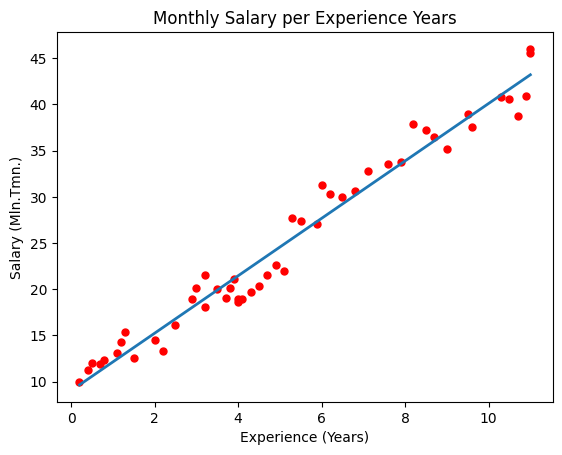

In [57]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'], 
           y=df['salary_linear'],
           c='r', 
           s=25)

# y = a * x + b
# y = coefficient * x + intercept
x_fit_lin = df['experience_years']
y_fit_lin = model_reg_lin.coef_ * x_fit_lin + model_reg_lin.intercept_

ax.plot(x_fit_lin, y_fit_lin, lw=2)
ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.show()

In [58]:
# Predict unknown numbers
model_reg_lin.predict(np.array([5]).reshape(-1, 1))

array([24.56490145])

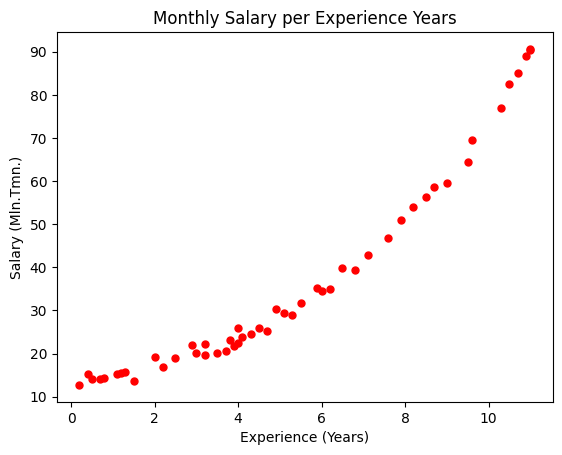

In [47]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'],
           y=df['salary_curve'],
           c='r', 
           s=25)

ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.show()

In [28]:
model_reg_crv = LinearRegression()

model_reg_crv.fit(
    X=df['experience_years'].to_numpy().reshape(-1, 1),
    y=df['salary_curve']
)

LinearRegression()

In [29]:
model_reg_crv.coef_, model_reg_crv.intercept_

(array([6.8615907]), 0.836451521624852)

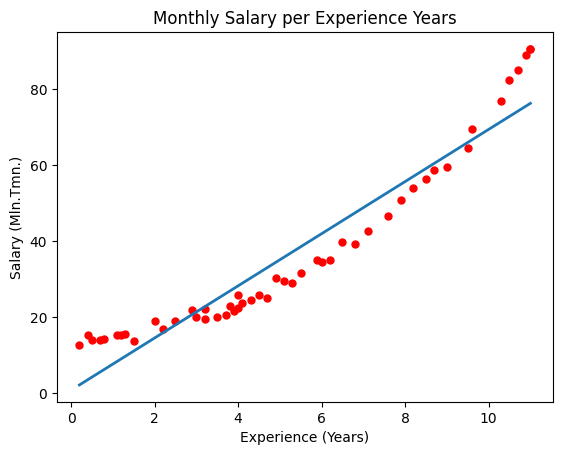

In [54]:
ax = plt.subplot()
ax.scatter(x=df['experience_years'],
           y=df['salary_curve'], 
           c='r', 
           s=25)

# y = a * x + b
# y = coefficient * x + intercept
x_fit_crv = df['experience_years']
y_fit_crv = model_reg_crv.coef_ * x_fit_crv + model_reg_crv.intercept_

ax.plot(x_fit_crv, y_fit_crv, lw=2)
ax.set_title('Monthly Salary per Experience Years')
ax.set_xlabel('Experience (Years)')
ax.set_ylabel('Salary (Mln.Tmn.)')
plt.show()

In [183]:
# Predict unknown numbers
model_reg_crv.predict(np.array([5]).reshape(-1, 1))

array([35.14440504])

In [63]:
# Using SKLearn Metrics > R-Squared
r2_linear = r2_score(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_lin)
r2_curve = r2_score(y_true=df['salary_curve'].to_numpy().reshape(-1, 1), y_pred=y_fit_crv)

print(f'R-Squared for the linear model:\t{round(r2_linear, 2)}')
print(f'R-Squared for the curve model:\t{round(r2_curve, 2)}')

R-Squared for the linear model:	0.97
R-Squared for the curve model:	0.91


In [62]:
# Using SKLearn Metrics > MSE
mse_linear = mean_squared_error(y_true=df['salary_linear'].to_numpy().reshape(-1, 1), y_pred=y_fit_lin)
mse_curve = mean_squared_error(y_true=df['salary_curve'].to_numpy().reshape(-1, 1), y_pred=y_fit_crv)

print(f'MSE for the linear model:\t{round(mse_linear, 2)}')
print(f'MSE for the curve model:\t{round(mse_curve, 2)}')

MSE for the linear model:	3.33
MSE for the curve model:	46.95
